In [ ]:
#Euclidean
import numpy as np
from scipy.spatial import distance
pA=np.array([2,4,6])
pB=np.array([5,6,7])
ed=distance.euclidean(pA,pB)
print("euclidean distnace",ed)

se=1/(1+ed)
print("euclidean Similarity:",se)



euclidean distnace 3.7416573867739413
euclidean Similarity: 0.21089672205953397


In [ ]:
#Manhanttan
import numpy as np
from scipy.spatial import distance

pA=np.array([2,4,6])
pB=np.array([3, 5, 7])
md=distance.cityblock(pA,pB)
print("Mahanttan distance: ",md)
se=1/(1+md)
print("Similarity : ",se)


Mahanttan distance:  3
Similarity :  0.25


In [ ]:
import numpy as np
from scipy.spatial import distance
pA=np.array([2,4,6])
pB=np.array([5,1,9])

md=distance.minkowski(pA,pB,p=3)
print("Minkowski :",md)
se=1/(1+md)
print("Similarity: ",se)


Minkowski : 4.3267487109222245
Similarity:  0.1877317767871331


In [ ]:
#pearson correlation
import pandas as pd
from scipy.stats import pearsonr
tips=pd.read_csv("tips.csv")
corr,p=pearsonr(tips['total_bill'],tips['tip'])
print(f"Pearson correlation coefficient:{corr}")
print(f"P-value:{p}")

Pearson correlation coefficient:0.6757341092113647
P-value:6.692470646863279e-34


In [ ]:
#Spearman correlation
import pandas as pd
from scipy.stats import spearmanr
df=pd.DataFrame({
    'X':[10,20,30,40,50],
    'Y':[12,18,33,47,55]
})
corr,p=spearmanr(df['X'],df['Y'])
print(f"Spearman correlation coefficient:{corr}")
print(f"P-value:{p}")

Spearman correlation coefficient:0.9999999999999999
P-value:1.4042654220543672e-24


In [ ]:
#Hamming distance
def Hamming_distance(str1,str2):
  if len(str1)!=len(str2):
    raise ValueError("Strings must be of equal length")

  return sum(ch1!=ch2 for ch1,ch2 in zip(str1,str2))

s1="karolin"
s2="kathrin"
dist = Hamming_distance(s1,s2)
print("Hamming distance between ",s1,"and",s2," is:",dist)

Hamming distance between  karolin and kathrin  is: 3


In [ ]:
#Jacard Index
def jacard_index(s1,s2):
  set1,set2=set(s1.split()),set(s2.split())
  intersection=set1.intersection(set2)
  union=set1.union(set2)
  return len(intersection)/len(union)

s1="data science is fun"
s2="science makes data useful "
print("Jacard Index:",jacard_index(s1,s2))

Jacard Index: 0.3333333333333333


In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity
s1="data science is fun"
s2="science makes data useful"
vectorizer=CountVectorizer().fit([s1,s2])
vectors=vectorizer.transform([s1,s2])
cos_sin=cosine_similarity(vectors[0],vectors[1])[0][0]
print("Cosine Similarity:",cos_sin)

Cosine Similarity: 0.5


In [ ]:
def lcs_length(X, Y):
  m, n = len(X), len(Y)
  dp = [[0] * (n + 1) for _ in range(m + 1)]
  for i in range(m):
    for j in range(n):
      if X[i] == Y[j]:
        dp[i + 1][j + 1] = dp[i][j] + 1
      else:
        dp[i + 1][j + 1] = max(dp[i][j + 1], dp[i + 1][j])
  return dp[m][n]
seq1 = "ABCDEF"
seq2 = "AEBDF"
length = lcs_length(seq1, seq2)
print("Longest Common Subsequence Length:", length)

Longest Common Subsequence Length: 4


Objective: Classification: Survived (Yes/No)
Success Criteria: Accuracy > 80%
Constraints: Limited features, missing values, imbalanced classes

Dataset Shape: (891, 15)

First 5 Rows:
   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  

Data After Preprocessing:
   surv

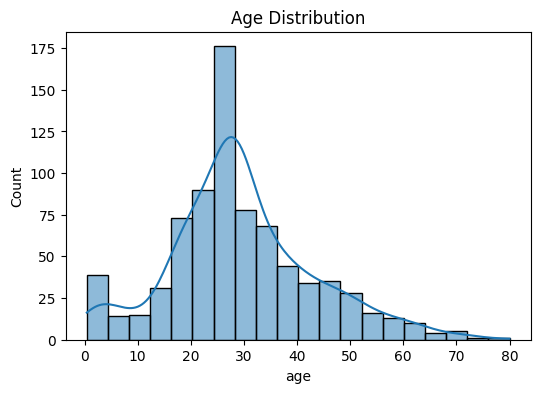

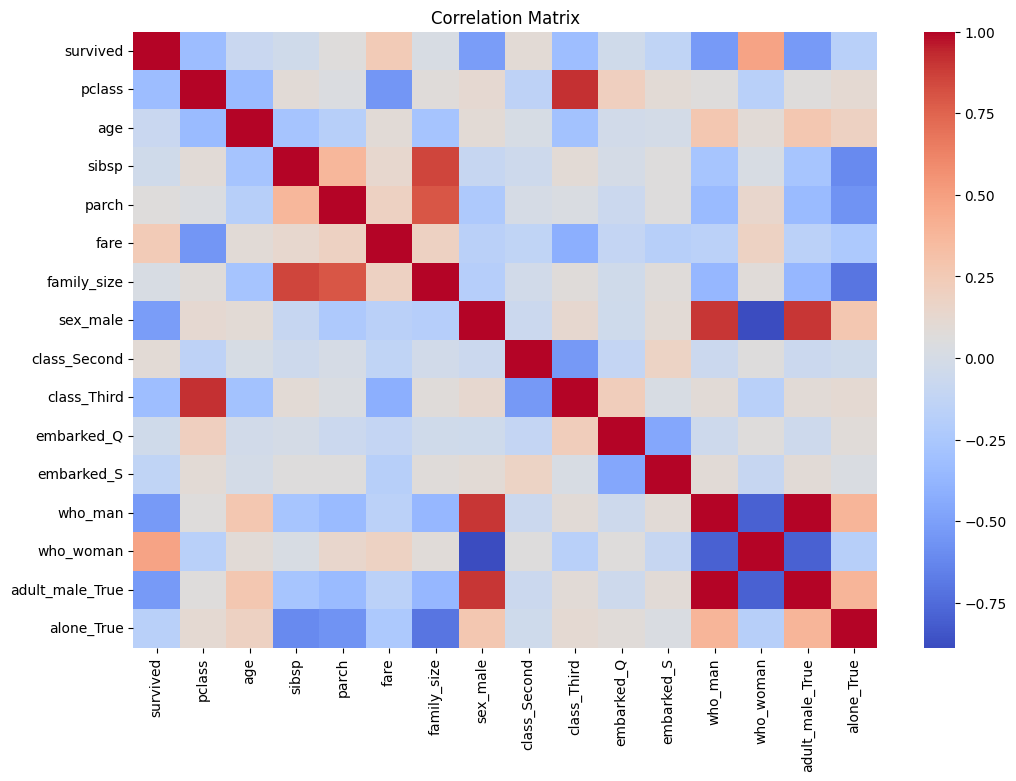


===== Model Evaluation =====
Accuracy : 0.8193548387096774
Precision: 0.7758620689655172
Recall   : 0.75

Confusion Matrix:
[[82 13]
 [15 45]]

First 10 Predictions:
[0 0 0 1 1 1 0 0 0 1]


In [ ]:
# 1. Import Libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix
)

# ==============================
# 2. Define the Problem
# ==============================

objective = "Classification: Survived (Yes/No)"
success_criteria = "Accuracy > 80%"
constraints = "Limited features, missing values, imbalanced classes"

print("Objective:", objective)
print("Success Criteria:", success_criteria)
print("Constraints:", constraints)

# ==============================
# 3. Data Collection
# ==============================

df = sns.load_dataset("titanic")

print("\nDataset Shape:", df.shape)
print("\nFirst 5 Rows:")
print(df.head())

# ==============================
# 4. Data Cleaning & Preprocessing
# ==============================

# Handle Missing Values
df['age'] = df['age'].fillna(df['age'].median())
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])

# Drop column with many missing values
df.drop(columns=['deck'], inplace=True)

# Remove duplicates
df.drop_duplicates(inplace=True)

# Feature Engineering
df['family_size'] = df['sibsp'] + df['parch']

# Convert categorical variables to numerical
df = pd.get_dummies(
    df,
    columns=[
        'sex',
        'class',
        'embarked',
        'who',
        'adult_male',
        'alone'
    ],
    drop_first=True
)

print("\nData After Preprocessing:")
print(df.head())

# ==============================
# 5. Exploratory Data Analysis
# ==============================

# Histogram of Age
plt.figure(figsize=(6, 4))
sns.histplot(df['age'], bins=20, kde=True)
plt.title("Age Distribution")
plt.show()

# Correlation Matrix
plt.figure(figsize=(12, 8))
corr = df.corr(numeric_only=True)

sns.heatmap(
    corr,
    cmap="coolwarm",
    annot=False
)

plt.title("Correlation Matrix")
plt.show()

# ==============================
# 6. Data Modeling
# ==============================

# Define Features and Target
X = df.drop(columns=['survived'])
y = df['survived']

# Keep only numeric columns
X = X.select_dtypes(
    include=['int64', 'float64', 'bool']
)

# Convert boolean values to integers
X = X.astype(int)

# Split Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# Create Logistic Regression Model
model = LogisticRegression(max_iter=1000)

# Train Model
model.fit(X_train, y_train)

# ==============================
# 7. Model Evaluation
# ==============================

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print("\n===== Model Evaluation =====")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)

print("\nConfusion Matrix:")
print(cm)

# ==============================
# 8. Sample Prediction
# ==============================

print("\nFirst 10 Predictions:")
print(y_pred[:10])

In [ ]:
#PCA
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Load dataset
tips = sns.load_dataset("tips")

# Select numeric columns
numeric_cols = tips.select_dtypes(include=['float64','int64'])

# Step 1: Standardize the data (important for PCA)
scaler = StandardScaler()
scaled_data = scaler.fit_transform(numeric_cols)
# Step 2: Apply PCA
pca = PCA(n_components=2)   # project data into 2 dimensions
pca_result = pca.fit_transform(scaled_data)
# Step 3: Create a DataFrame with PCA results
pca_df = pd.DataFrame(data=pca_result, columns=['PC1','PC2'])
print("Explained variance ratio:", pca.explained_variance_ratio_)
print("\nPCA Result (first 5 rows):")
print(pca_df.head())


Explained variance ratio: [0.72627656 0.1730423 ]

PCA Result (first 5 rows):
        PC1       PC2
0 -1.348415  0.426746
1 -0.955740  1.093576
2  0.540971  0.122324
3  0.067789 -0.674616
4  1.408308  0.847661


Explained varinance ratio: [0.9912126 0.0087874]

LDa Result(first 5 rows)
        LD1       LD2  target
0  8.061800 -0.300421       0
1  7.128688  0.786660       0
2  7.489828  0.265384       0
3  6.813201  0.670631       0
4  8.132309 -0.514463       0


<function matplotlib.pyplot.show(close=None, block=None)>

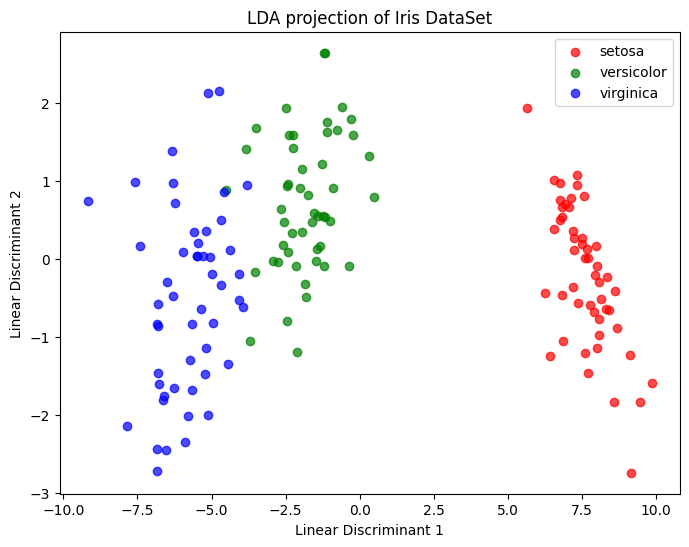

In [ ]:
#LDA
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
iris = load_iris()
X=iris.data
y=iris.target
lda=LinearDiscriminantAnalysis(n_components=2)
x=lda.fit_transform(X,y)
ld=pd.DataFrame(x,columns=['LD1','LD2'])
ld['target']=y
print("Explained varinance ratio:",lda.explained_variance_ratio_)
print("\nLDa Result(first 5 rows)")
print(ld.head())
plt.figure(figsize=(8,6))
for label,color in zip([0,1,2],['red','green','blue']):
  plt.scatter(
      ld.loc[ld['target']==label,'LD1'],
      ld.loc[ld['target']==label,'LD2'],
      label=iris.target_names[label],
      color=color,
      alpha=0.7
  )
plt.xlabel('Linear Discriminant 1')
plt.ylabel('Linear Discriminant 2')
plt.title('LDA projection of Iris DataSet')
plt.legend()
plt.show

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


t-SNE Result(first 5 rows):
       TSNE1     TSNE2  target
0 -24.284670 -0.196069       0
1 -21.731905  0.653882       0
2 -21.776773 -0.433848       0
3 -21.413086 -0.141203       0
4 -24.284908 -0.606254       0


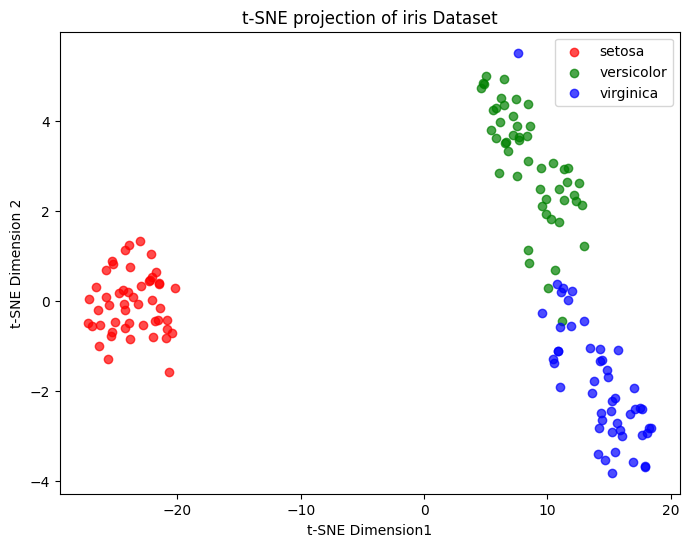

In [ ]:
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
iris=load_iris()
X=iris.data
y=iris.target
tsne=TSNE(n_components=2,random_state=42,perplexity=30,n_iter=1000)
x=tsne.fit_transform(X)
tsn=pd.DataFrame(x,columns=['TSNE1','TSNE2'])
tsn['target']=y
print("t-SNE Result(first 5 rows):")
print(tsn.head())
plt.figure(figsize=(8,6))
for label,color in zip([0,1,2],['red','green','blue']):
  plt.scatter(
      tsn.loc[tsn['target']==label,'TSNE1'],
      tsn.loc[tsn['target']==label,'TSNE2'],
      label=iris.target_names[label],
      color=color,
      alpha=0.7
  )
plt.xlabel('t-SNE Dimension1')
plt.ylabel('t-SNE Dimension 2')
plt.title('t-SNE projection of iris Dataset')
plt.legend()
plt.show()


In [ ]:
import pandas as pd
from sklearn.datasets import load_iris
from statistics import mode
iris=load_iris()
df=pd.DataFrame(iris.data,columns=iris.feature_names)
print("First 5  rows of dataset")
print(df.head())
meanv=df.mean()
print("\nMean Values:")
print(meanv)
medianv=df.median()
print("\nMedian Value:")
print(medianv)
modev=df.mode().iloc[0]
print("\nMode Values.")
print(modev)

First 5  rows of dataset
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2

Mean Values:
sepal length (cm)    5.843333
sepal width (cm)     3.057333
petal length (cm)    3.758000
petal width (cm)     1.199333
dtype: float64

Median Value:
sepal length (cm)    5.80
sepal width (cm)     3.00
petal length (cm)    4.35
petal width (cm)     1.30
dtype: float64

Mode Values.
sepal length (cm)    5.0
sepal width (cm)     3.0
petal length (cm)    1.4
petal width (cm)     0.2
Name: 0, dtype: float64


In [ ]:
import pandas as pd
from sklearn.datasets import load_iris
iris=load_iris()
df=pd.DataFrame(iris.data,columns=iris.feature_names)
print("\nFirst 5 rows of datset")
print(df.head())
rangev=df.max()-df.min()
print("\nRange Values:",rangev)
variancev=df.var()
print("\nVariance Values: ",variancev)
std=df.std()
print("\nStandard Deviation: ",std)
q1=df.quantile(0.25)
q3=df.quantile(0.75)
print("\nInterquartile Range:",(q3-q1))


First 5 rows of datset
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2

Range Values: sepal length (cm)    3.6
sepal width (cm)     2.4
petal length (cm)    5.9
petal width (cm)     2.4
dtype: float64

Variance Values:  sepal length (cm)    0.685694
sepal width (cm)     0.189979
petal length (cm)    3.116278
petal width (cm)     0.581006
dtype: float64

Standard Deviation:  sepal length (cm)    0.828066
sepal width (cm)     0.435866
petal length (cm)    1.765298
petal width (cm)     0.762238
dtype: float64

Interquartile Range: sepal length (cm)    1.3
sepal width (cm)     0.5
petal l

In [ ]:
import pandas as pd
from sklearn.datasets import load_iris
iris = load_iris()
df=pd.DataFrame(iris.data,columns=iris.feature_names)
print("First 5 rows of dataset ")
print(df.head())
skewn=df.skew()
print("\nSkewness Values:")
print(skewn)
kurtosisv=df.kurt()
print("\nKurtosis Values")
print(kurtosisv)


First 5 rows of dataset 
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2

Skewness Values:
sepal length (cm)    0.314911
sepal width (cm)     0.318966
petal length (cm)   -0.274884
petal width (cm)    -0.102967
dtype: float64

Kurtosis Values
sepal length (cm)   -0.552064
sepal width (cm)     0.228249
petal length (cm)   -1.402103
petal width (cm)    -1.340604
dtype: float64


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
iris=load_iris()
df=pd.DataFrame(iris.data,columns=iris.feature_names)
df['species']=iris.target
plt.figure(figsize=(6,4))
sns.boxplot(x=df['sepallength(cm)'])
plt.title("Boxplot of Sepallength")
plt.show()


KeyError: 'sepallength(cm)'

<Figure size 600x400 with 0 Axes>